In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

Current working directory:
c:\Users\ttnkashe\Documents\recurrent-staged-loras\notebooks


In [4]:
from pathlib import Path

for p in Path(".").glob("**/metrics.json"):
    print(p)

In [5]:
RUNS = {
    "Base": "../outputs/base/base_debug_seed7/metrics.json",
    "Standard LoRA": "../outputs/standard_lora/standard_lora_debug_seed7/metrics.json",
    "Shared Recurrence": "../outputs/shared_recurrence/shared_recurrence_debug_seed7/metrics.json",
    "Stage-Specialized": "../outputs/stage_specialized_recurrence/stage_specialized_recurrence_debug_seed7/metrics.json",
}

metrics = {}

for name, path in RUNS.items():
    path = Path(path)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            metrics[name] = json.load(f)
    else:
        print(f"Missing: {path}")

metrics.keys()

dict_keys(['Base', 'Standard LoRA', 'Shared Recurrence', 'Stage-Specialized'])

In [ ]:
rows = []

for name, m in metrics.items():
    rows.append({
        "Model": name,
        "Train Loss": m.get("final_train_loss"),
        "Eval Loss": m.get("final_eval_loss"),
        "Eval PPL": m.get("eval_perplexity"),
        "Stage 2 Acc": m.get("stage_2_token_accuracy"),
        "Stage 3 Acc": m.get("stage_3_token_accuracy"),
        "Trainable Params": m.get("trainable_params"),
        "Steps": m.get("global_steps_completed"),
    })

df = pd.DataFrame(rows)
df

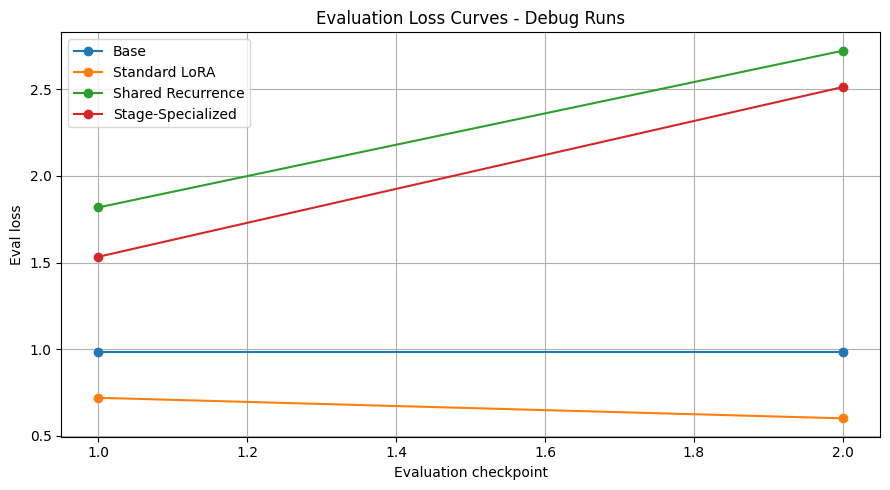

In [7]:
plt.figure(figsize=(9, 5))

for name, m in metrics.items():
    losses = m.get("eval_loss_history", [])
    if losses:
        plt.plot(range(1, len(losses) + 1), losses, marker="o", label=name)

plt.title("Evaluation Loss Curves - Debug Runs")
plt.xlabel("Evaluation checkpoint")
plt.ylabel("Eval loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

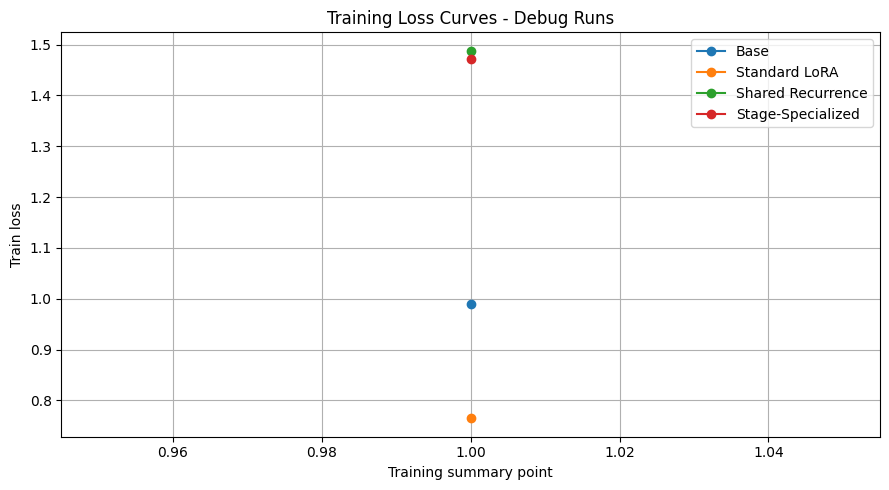

In [8]:
plt.figure(figsize=(9, 5))

for name, m in metrics.items():
    losses = m.get("train_loss_history", [])
    if losses:
        plt.plot(range(1, len(losses) + 1), losses, marker="o", label=name)

plt.title("Training Loss Curves - Debug Runs")
plt.xlabel("Training summary point")
plt.ylabel("Train loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

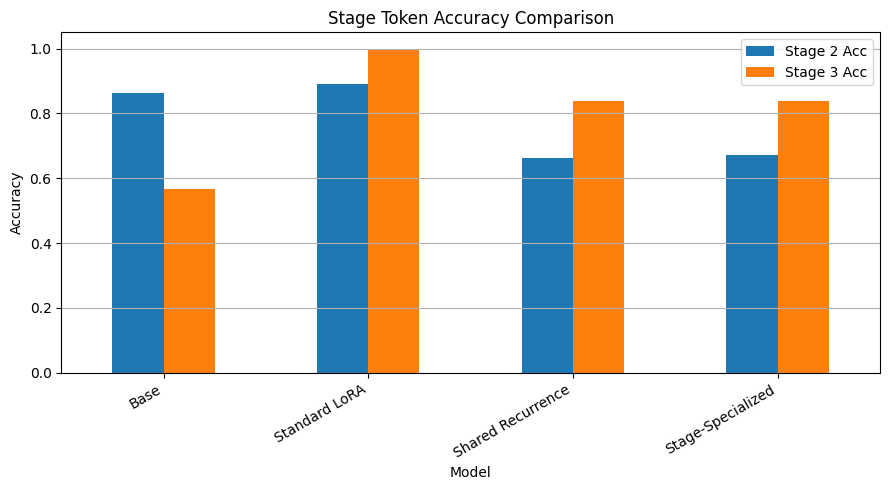

In [9]:
df_plot = df.set_index("Model")[["Stage 2 Acc", "Stage 3 Acc"]]

df_plot.plot(kind="bar", figsize=(9, 5))
plt.title("Stage Token Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

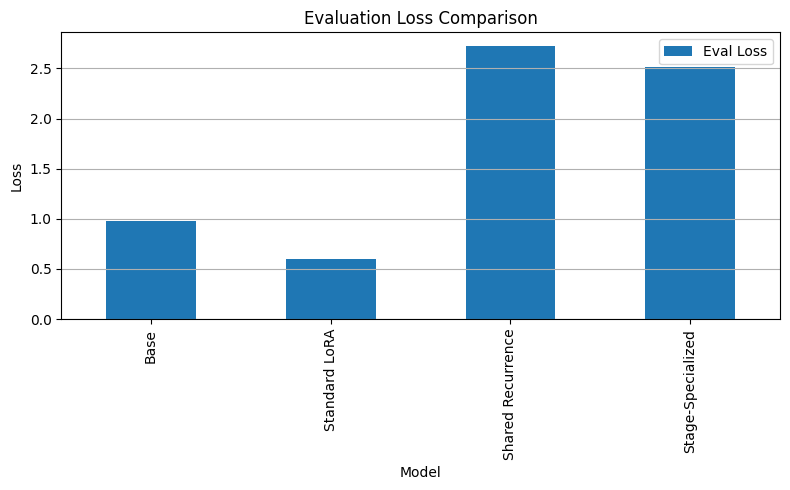

In [10]:
df_plot = df.set_index("Model")[["Eval Loss"]]

ax = df_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Evaluation Loss Comparison")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.tight_layout()
plt.show()